In [ ]:
!pip install scikit-optimize
!pip install skopt
!pip install --upgrade pip
!pip install scikit-optimize
!pip install xgboost

ERROR: Could not find a version that satisfies the requirement skopt (from versions: none)
ERROR: No matching distribution found for skopt


  Using cached pip-25.3-py3-none-any.whl.metadata (4.7 kB)
Using cached pip-25.3-py3-none-any.whl (1.8 MB)


ERROR: To modify pip, please run the following command:
C:\Users\Zakaria\anaconda3\python.exe -m pip install --upgrade pip


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,f1_score
from sklearn.preprocessing import PolynomialFeatures,OneHotEncoder
from sklearn.linear_model import LogisticRegression

## Read dataset

In [5]:
df = pd.read_csv("/content/final_df_bgd_bgd_bgd_top30.csv")
df.head(319)

,cv_id,jd_id,matched_weight,required_weight,match_ratio,missing_required_skills_count,missing_hard_skills,missing_soft_skills,required_hard_skills,required_soft_skills,...,feat_68,feat_117,feat_76,feat_11,feat_88,feat_94,feat_27,feat_82,feat_78,feat_8
0,1,1,1,1,1.000000,0,[],['adaptability'],['ai'],"['teamwork', 'leadership', 'customer focus', '...",...,3.229312,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.755820,-1.397419,-2.142967
1,1,2,3,4,0.750000,1,['systems engineering'],"['communication', 'problem solving']","['ai', 'systems engineering', 'financial analy...","['communication', 'problem solving']",...,3.229312,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.755820,-1.397419,-2.142967
2,1,3,1,3,0.333333,2,"['marketing', 'microsoft office']",[],"['ai', 'marketing', 'microsoft office']","['teamwork', 'leadership', 'growth mindset']",...,3.229312,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.755820,-1.397419,-2.142967
3,1,4,1,3,0.333333,2,"['sales', 'product management']","['problem solving', 'time management', 'work e...","['ai', 'sales', 'product management']","['problem solving', 'leadership', 'time manage...",...,3.229312,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.755820,-1.397419,-2.142967
4,1,5,5,8,0.625000,3,"['networking', 'sales', 'product management']","['problem solving', 'adaptability', 'attention...","['ai', 'models', 'reporting', 'networking', 's...","['teamwork', 'problem solving', 'leadership', ...",...,3.229312,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.755820,-1.397419,-2.142967
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314,1,315,2,5,0.400000,3,"['sales', 'marketing', 'product management']","['problem solving', 'adaptability', 'attention...","['ai', 'sales', 'marketing', 'product manageme...","['teamwork', 'problem solving', 'leadership', ...",...,3.229312,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.755820,-1.397419,-2.142967
315,1,316,3,6,0.500000,3,"['sales', 'marketing', 'product management']","['time management', 'adaptability', 'attention...","['ai', 'reporting', 'sales', 'marketing', 'pro...","['leadership', 'time management', 'customer fo...",...,3.229312,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.755820,-1.397419,-2.142967
316,1,317,2,3,0.666667,1,['sales'],['communication'],"['ai', 'sales', 'recruitment']","['communication', 'teamwork', 'leadership', 'c...",...,3.229312,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.755820,-1.397419,-2.142967
317,1,318,3,6,0.500000,3,"['sales', 'product management', 'microsoft off...","['communication', 'attention to detail']","['ai', 'sales', 'product management', 'project...","['communication', 'teamwork', 'customer focus'...",...,3.229312,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.755820,-1.397419,-2.142967


In [ ]:
df.columns

Index(['cv_id', 'jd_id', 'matched_weight', 'required_weight', 'match_ratio',
       'missing_required_skills_count', 'missing_hard_skills',
       'missing_soft_skills', 'required_hard_skills', 'required_soft_skills',
       'required_skill_count', 'soft_skill_match_score',
       'missing_soft_skills_new', 'missing_soft_skills_count_new', 'domain',
       'final_score', 'target', 'video_id', 'feat_95', 'feat_69', 'feat_125',
       'feat_20', 'feat_91', 'feat_68', 'feat_117', 'feat_76', 'feat_11',
       'feat_88', 'feat_94', 'feat_27', 'feat_82', 'feat_78', 'feat_8'],
      dtype='object')

In [ ]:
print(f"#cv*#jd = {df.shape[0]}")
print(f"fearures = {df.shape[1]}")

#cv*#jd = 10176
fearures = 33


In [ ]:
df.groupby("cv_id")["target"].nunique()

cv_id
1     2
2     2
3     2
4     2
5     2
6     2
7     2
8     2
9     2
10    2
11    2
12    2
13    2
14    2
15    2
16    2
17    2
18    2
19    2
20    2
21    2
22    2
23    2
24    2
25    2
26    2
27    2
28    2
29    2
30    2
31    2
32    2
Name: target, dtype: int64

In [ ]:
selected_cols = [
    'matched_weight',
    'required_weight',
    'required_skill_count',
    'missing_required_skills_count',
    'match_ratio',
    'missing_soft_skills_count_new',
    'domain',
    'feat_95', 'feat_69', 'feat_125',
    'feat_20', 'feat_91', 'feat_68',
    'feat_117', 'feat_76', 'feat_11',
    'feat_88', 'feat_94', 'feat_27',
    'feat_82', 'feat_78', 'feat_8',
    'target'
]

df_model = df[selected_cols].copy()

df_model = df_model.rename(
    columns={'match_ratio': 'hard_skill_match_ratio'}
)

df_model.head(30)

,matched_weight,required_weight,required_skill_count,missing_required_skills_count,hard_skill_match_ratio,missing_soft_skills_count_new,domain,feat_95,feat_69,feat_125,...,feat_117,feat_76,feat_11,feat_88,feat_94,feat_27,feat_82,feat_78,feat_8,target
0,1,1,5,0,1.000000,0,Support,-1.322632,1.406155,-2.846429,...,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967,1
1,3,4,6,1,0.750000,1,IT,-1.322632,1.406155,-2.846429,...,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967,1
2,1,3,6,2,0.333333,0,Business,-1.322632,1.406155,-2.846429,...,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967,0
3,1,3,9,2,0.333333,1,Business,-1.322632,1.406155,-2.846429,...,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967,0
4,5,8,18,3,0.625000,2,Business,-1.322632,1.406155,-2.846429,...,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967,1
5,5,11,18,6,0.454545,1,Finance,-1.322632,1.406155,-2.846429,...,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967,0
6,5,8,19,3,0.625000,3,Engineering,-1.322632,1.406155,-2.846429,...,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967,1
7,3,7,18,4,0.428571,2,Finance,-1.322632,1.406155,-2.846429,...,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967,0
8,1,3,6,2,0.333333,0,Business,-1.322632,1.406155,-2.846429,...,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967,0
9,4,8,18,4,0.500000,1,Administrative,-1.322632,1.406155,-2.846429,...,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967,1


# Encode Domain

In [ ]:
len(df_model['domain'].unique())

13

In [ ]:
df_model['domain'].value_counts()

domain
IT                2240
Engineering       2080
Business          1504
Finance           1248
HR                1184
Support            576
Administrative     416
Research           256
Management         192
Operations         160
Analytics          128
Creative            96
Consulting          96
Name: count, dtype: int64

In [ ]:
le = LabelEncoder()
df_model["domain_encoded"] = le.fit_transform(df["domain"])
df_model_encoded = df_model.drop(columns=['domain'])

In [ ]:
df_model_encoded.head(32)

,matched_weight,required_weight,required_skill_count,missing_required_skills_count,hard_skill_match_ratio,missing_soft_skills_count_new,feat_95,feat_69,feat_125,feat_20,...,feat_76,feat_11,feat_88,feat_94,feat_27,feat_82,feat_78,feat_8,target,domain_encoded
0,1,1,5,0,1.000000,0,-1.322632,1.406155,-2.846429,1.291473,...,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967,1,12
1,3,4,6,1,0.750000,1,-1.322632,1.406155,-2.846429,1.291473,...,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967,1,8
2,1,3,6,2,0.333333,0,-1.322632,1.406155,-2.846429,1.291473,...,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967,0,2
3,1,3,9,2,0.333333,1,-1.322632,1.406155,-2.846429,1.291473,...,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967,0,2
4,5,8,18,3,0.625000,2,-1.322632,1.406155,-2.846429,1.291473,...,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967,1,2
5,5,11,18,6,0.454545,1,-1.322632,1.406155,-2.846429,1.291473,...,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967,0,6
6,5,8,19,3,0.625000,3,-1.322632,1.406155,-2.846429,1.291473,...,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967,1,5
7,3,7,18,4,0.428571,2,-1.322632,1.406155,-2.846429,1.291473,...,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967,0,6
8,1,3,6,2,0.333333,0,-1.322632,1.406155,-2.846429,1.291473,...,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967,0,2
9,4,8,18,4,0.500000,1,-1.322632,1.406155,-2.846429,1.291473,...,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967,1,0


In [ ]:
df_model_encoded.describe()

,matched_weight,required_weight,required_skill_count,missing_required_skills_count,hard_skill_match_ratio,missing_soft_skills_count_new,feat_95,feat_69,feat_125,feat_20,...,feat_76,feat_11,feat_88,feat_94,feat_27,feat_82,feat_78,feat_8,target,domain_encoded
count,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000,...,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000,10176.000000
mean,2.697229,8.056604,14.930818,5.359375,0.355347,2.589524,-0.488710,0.562177,-2.982411,0.989733,...,-1.148053,-0.520676,1.453815,2.034798,0.257880,-1.894128,-0.212491,-2.034668,0.232606,5.990566
std,1.854569,3.711876,5.594656,3.169213,0.211519,3.106187,1.361514,1.374077,1.964801,1.925915,...,1.511170,1.449669,1.761731,1.929322,2.058547,1.404351,1.657655,2.213251,0.422514,2.926371
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-4.268386,-1.553395,-7.444741,-4.796014,...,-4.367168,-2.321454,-1.294435,-0.721812,-3.909988,-5.804455,-2.693511,-7.364284,0.000000,0.000000
25%,1.000000,5.000000,11.000000,3.000000,0.200000,0.000000,-1.334173,-0.295707,-4.275203,0.297454,...,-2.523793,-1.494455,-0.013226,0.452038,-1.757183,-2.451491,-1.780795,-3.442146,0.000000,5.000000
50%,2.000000,8.000000,15.000000,5.000000,0.333333,1.000000,-0.493819,0.361695,-3.095893,1.499649,...,-0.871984,-0.475769,1.464662,1.816334,0.553244,-1.821362,-0.660611,-1.670098,0.000000,6.000000
75%,4.000000,11.000000,19.000000,7.000000,0.500000,5.000000,0.251136,1.414726,-1.154551,2.252898,...,-0.186382,-0.026943,2.640111,3.317204,1.931814,-1.115498,1.248693,-0.360628,0.000000,8.000000
max,12.000000,19.000000,29.000000,19.000000,1.000000,12.000000,2.660940,4.294547,0.085521,3.823320,...,1.327962,4.269791,6.336426,7.308219,3.683286,0.918401,2.939344,1.230159,1.000000,12.000000


In [ ]:
df_model_encoded.dtypes

matched_weight                     int64
required_weight                    int64
required_skill_count               int64
missing_required_skills_count      int64
hard_skill_match_ratio           float64
missing_soft_skills_count_new      int64
feat_95                          float64
feat_69                          float64
feat_125                         float64
feat_20                          float64
feat_91                          float64
feat_68                          float64
feat_117                         float64
feat_76                          float64
feat_11                          float64
feat_88                          float64
feat_94                          float64
feat_27                          float64
feat_82                          float64
feat_78                          float64
feat_8                           float64
target                             int64
domain_encoded                     int32
dtype: object

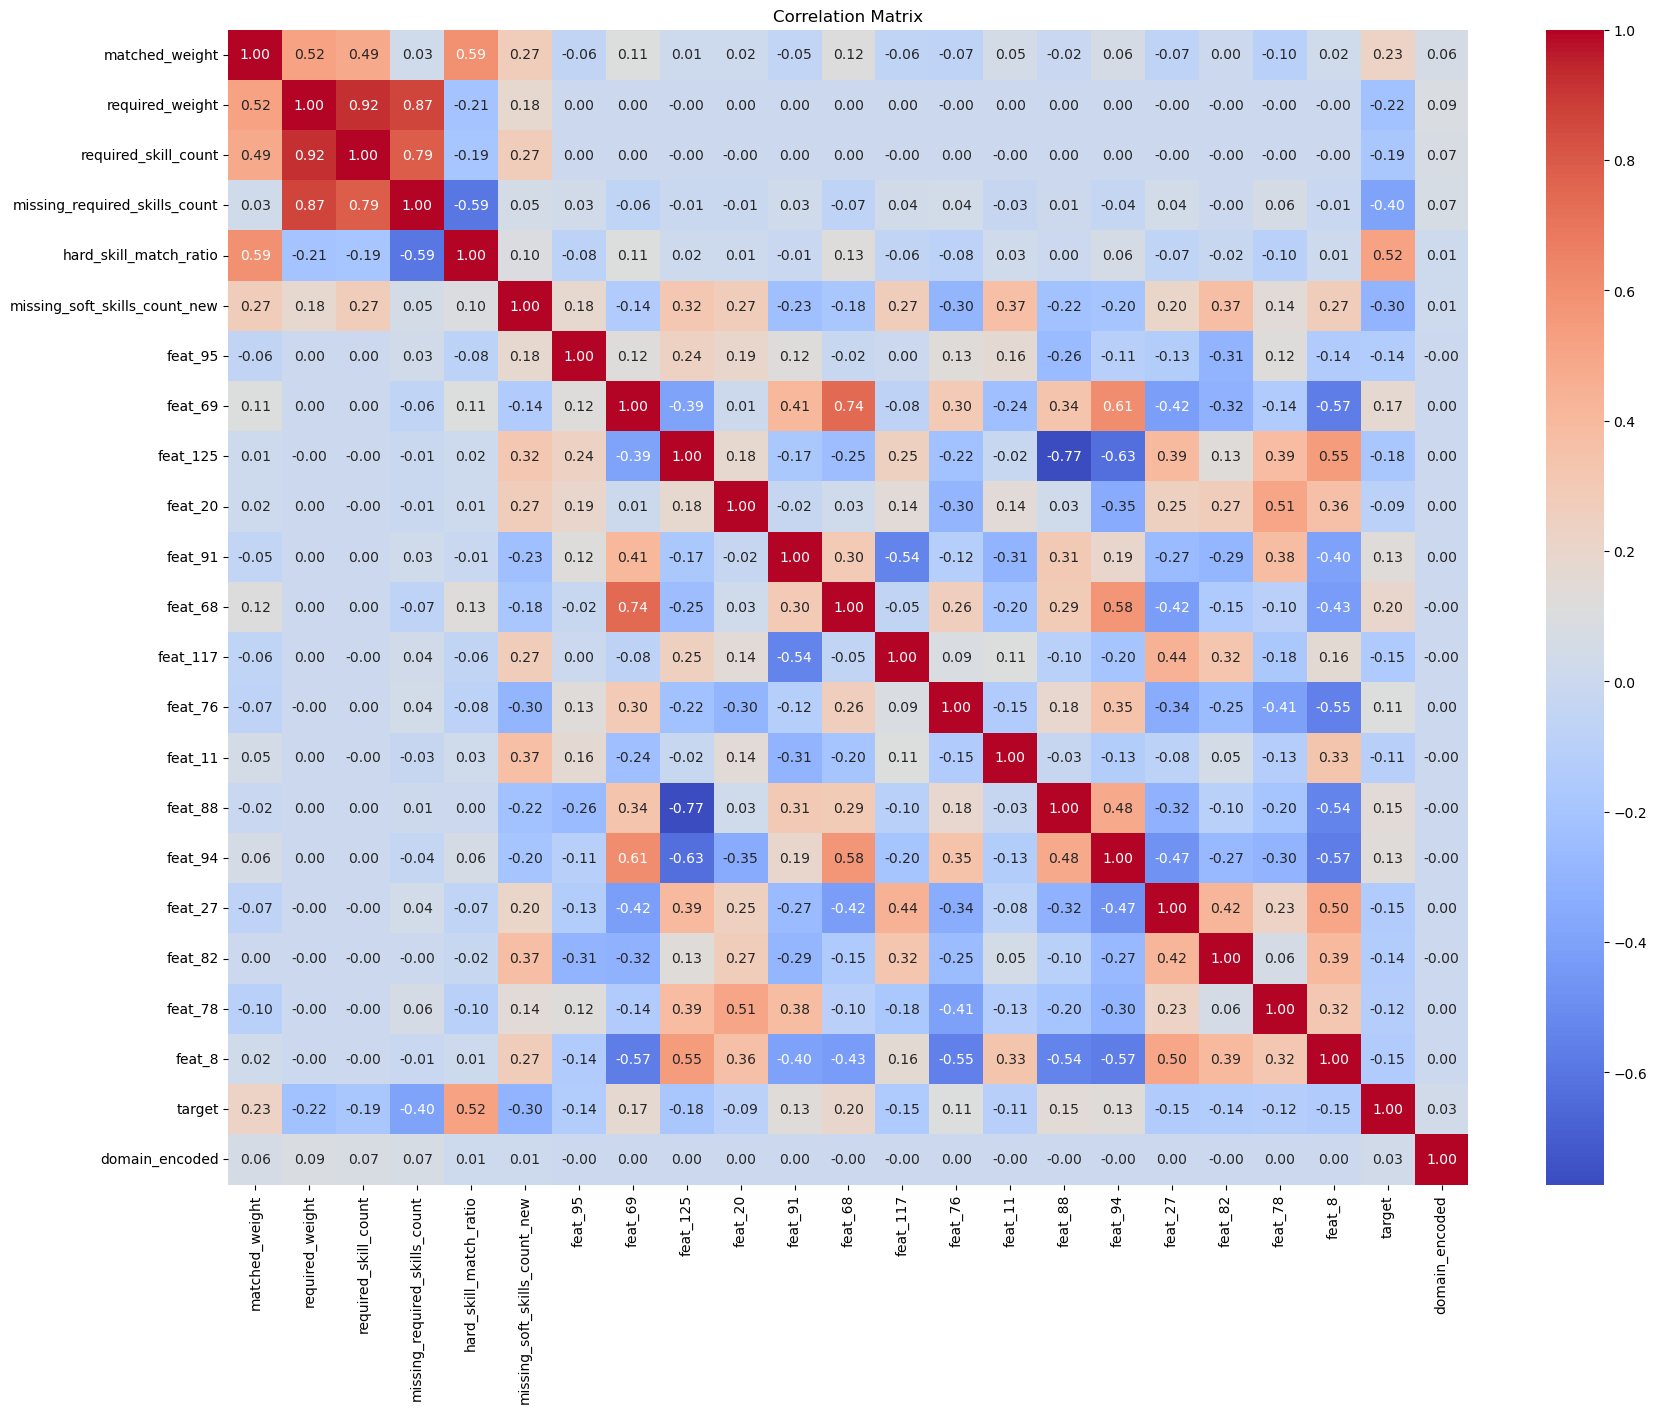

In [ ]:
correlation_matrix = df_model_encoded.corr()

plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [ ]:
df_model_encoded = df_model_encoded.drop(
    ['required_weight', 'required_skill_count'],
    axis=1
)
df_model_encoded.columns

Index(['matched_weight', 'missing_required_skills_count',
       'hard_skill_match_ratio', 'missing_soft_skills_count_new', 'feat_95',
       'feat_69', 'feat_125', 'feat_20', 'feat_91', 'feat_68', 'feat_117',
       'feat_76', 'feat_11', 'feat_88', 'feat_94', 'feat_27', 'feat_82',
       'feat_78', 'feat_8', 'target', 'domain_encoded'],
      dtype='object')

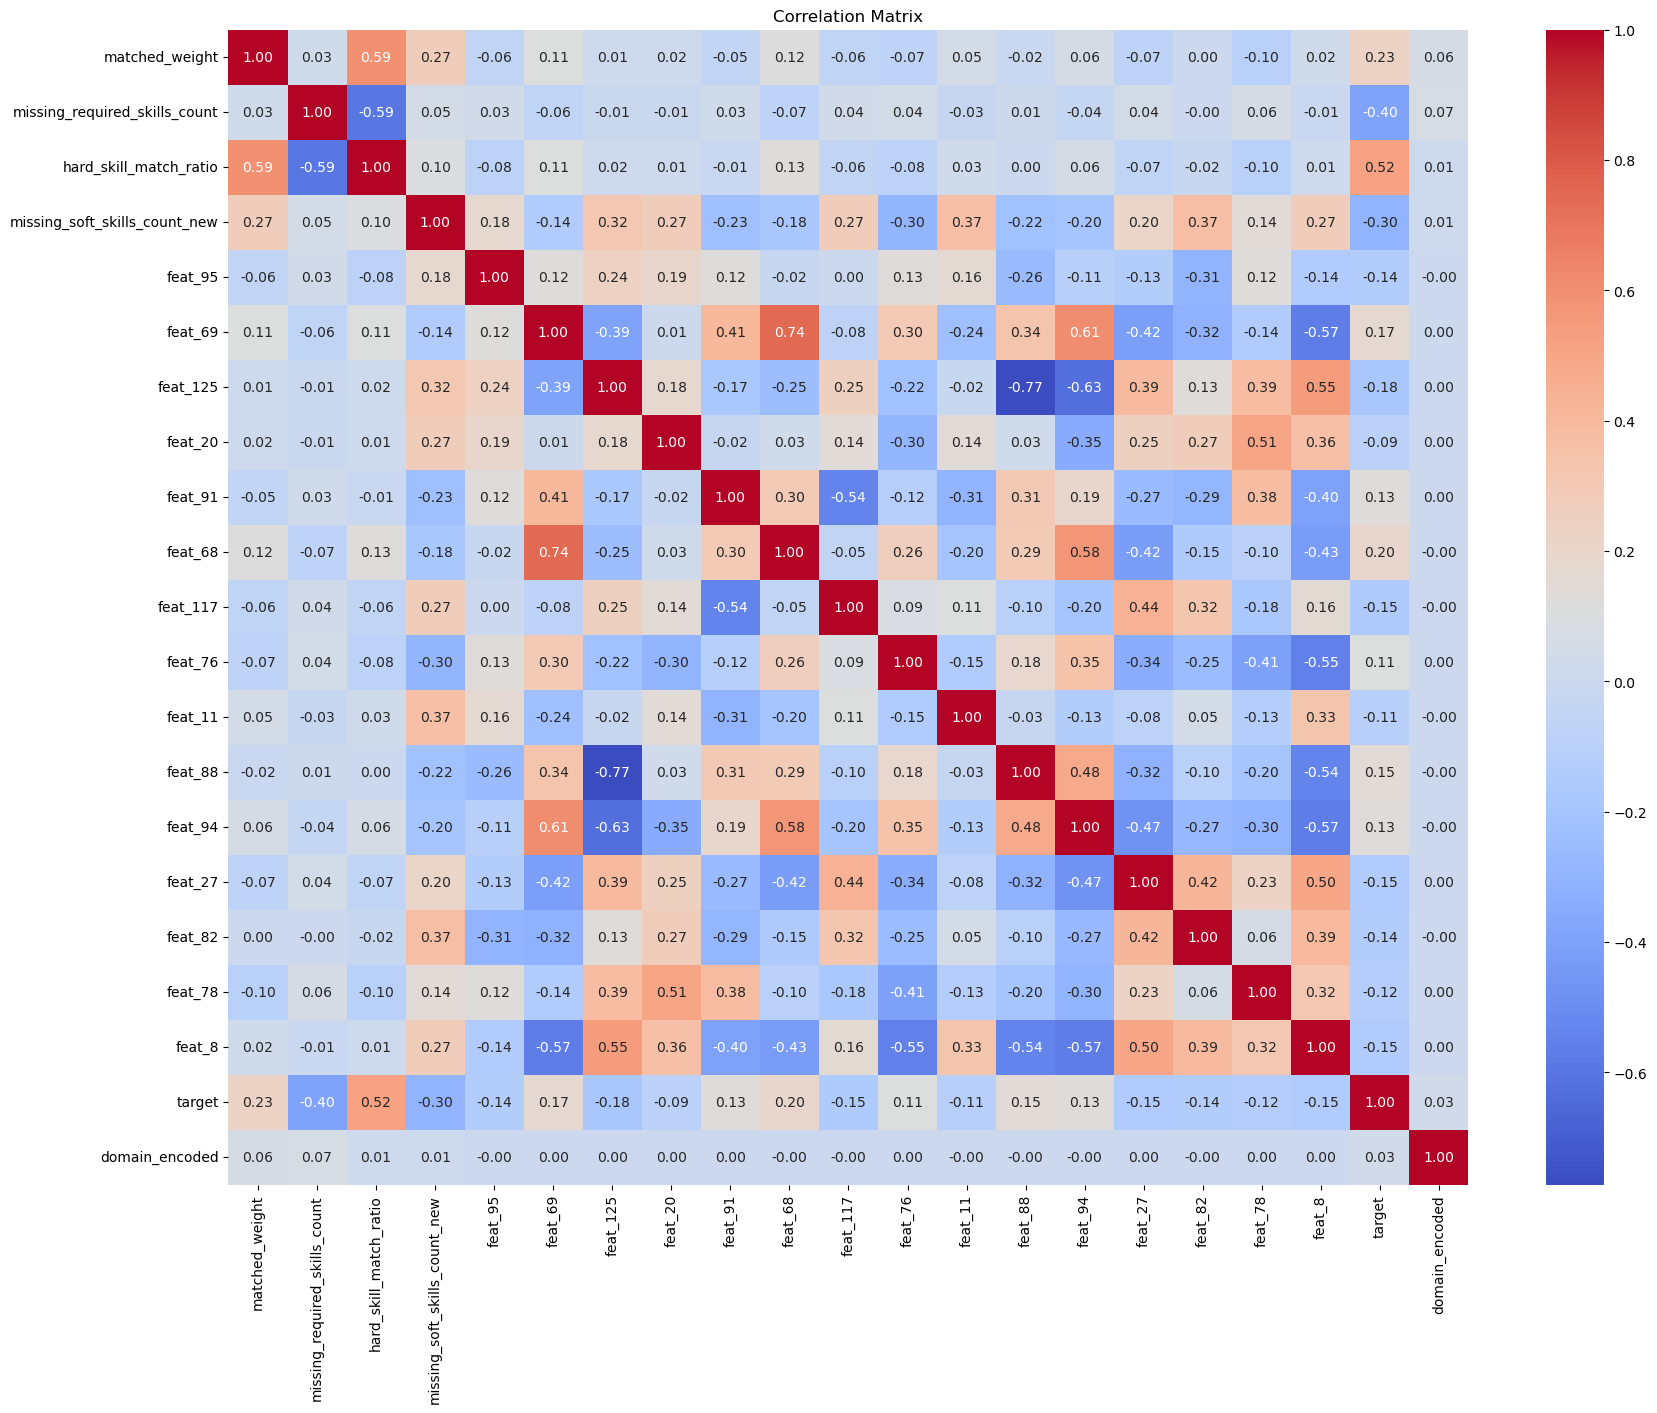

In [ ]:
correlation_matrix = df_model_encoded.corr()

plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [ ]:
df_model_encoded.corr(numeric_only=True)['target'].sort_values(ascending=False)

target                           1.000000
hard_skill_match_ratio           0.516234
matched_weight                   0.227853
feat_68                          0.196112
feat_69                          0.173417
feat_88                          0.146128
feat_94                          0.130470
feat_91                          0.129583
feat_76                          0.109968
domain_encoded                   0.031583
feat_20                         -0.087494
feat_11                         -0.110603
feat_78                         -0.123329
feat_95                         -0.136785
feat_82                         -0.141923
feat_8                          -0.145735
feat_27                         -0.148462
feat_117                        -0.149357
feat_125                        -0.178819
missing_soft_skills_count_new   -0.304514
missing_required_skills_count   -0.395799
Name: target, dtype: float64

## Correlation analysis shows that hard skill match ratio is the strongest predictor of job relevance, followed by soft skill match score. Missing required skills exhibit strong negative correlation with the relevance label, confirming their importance. Domain features act as contextual signals rather than primary decision factors.

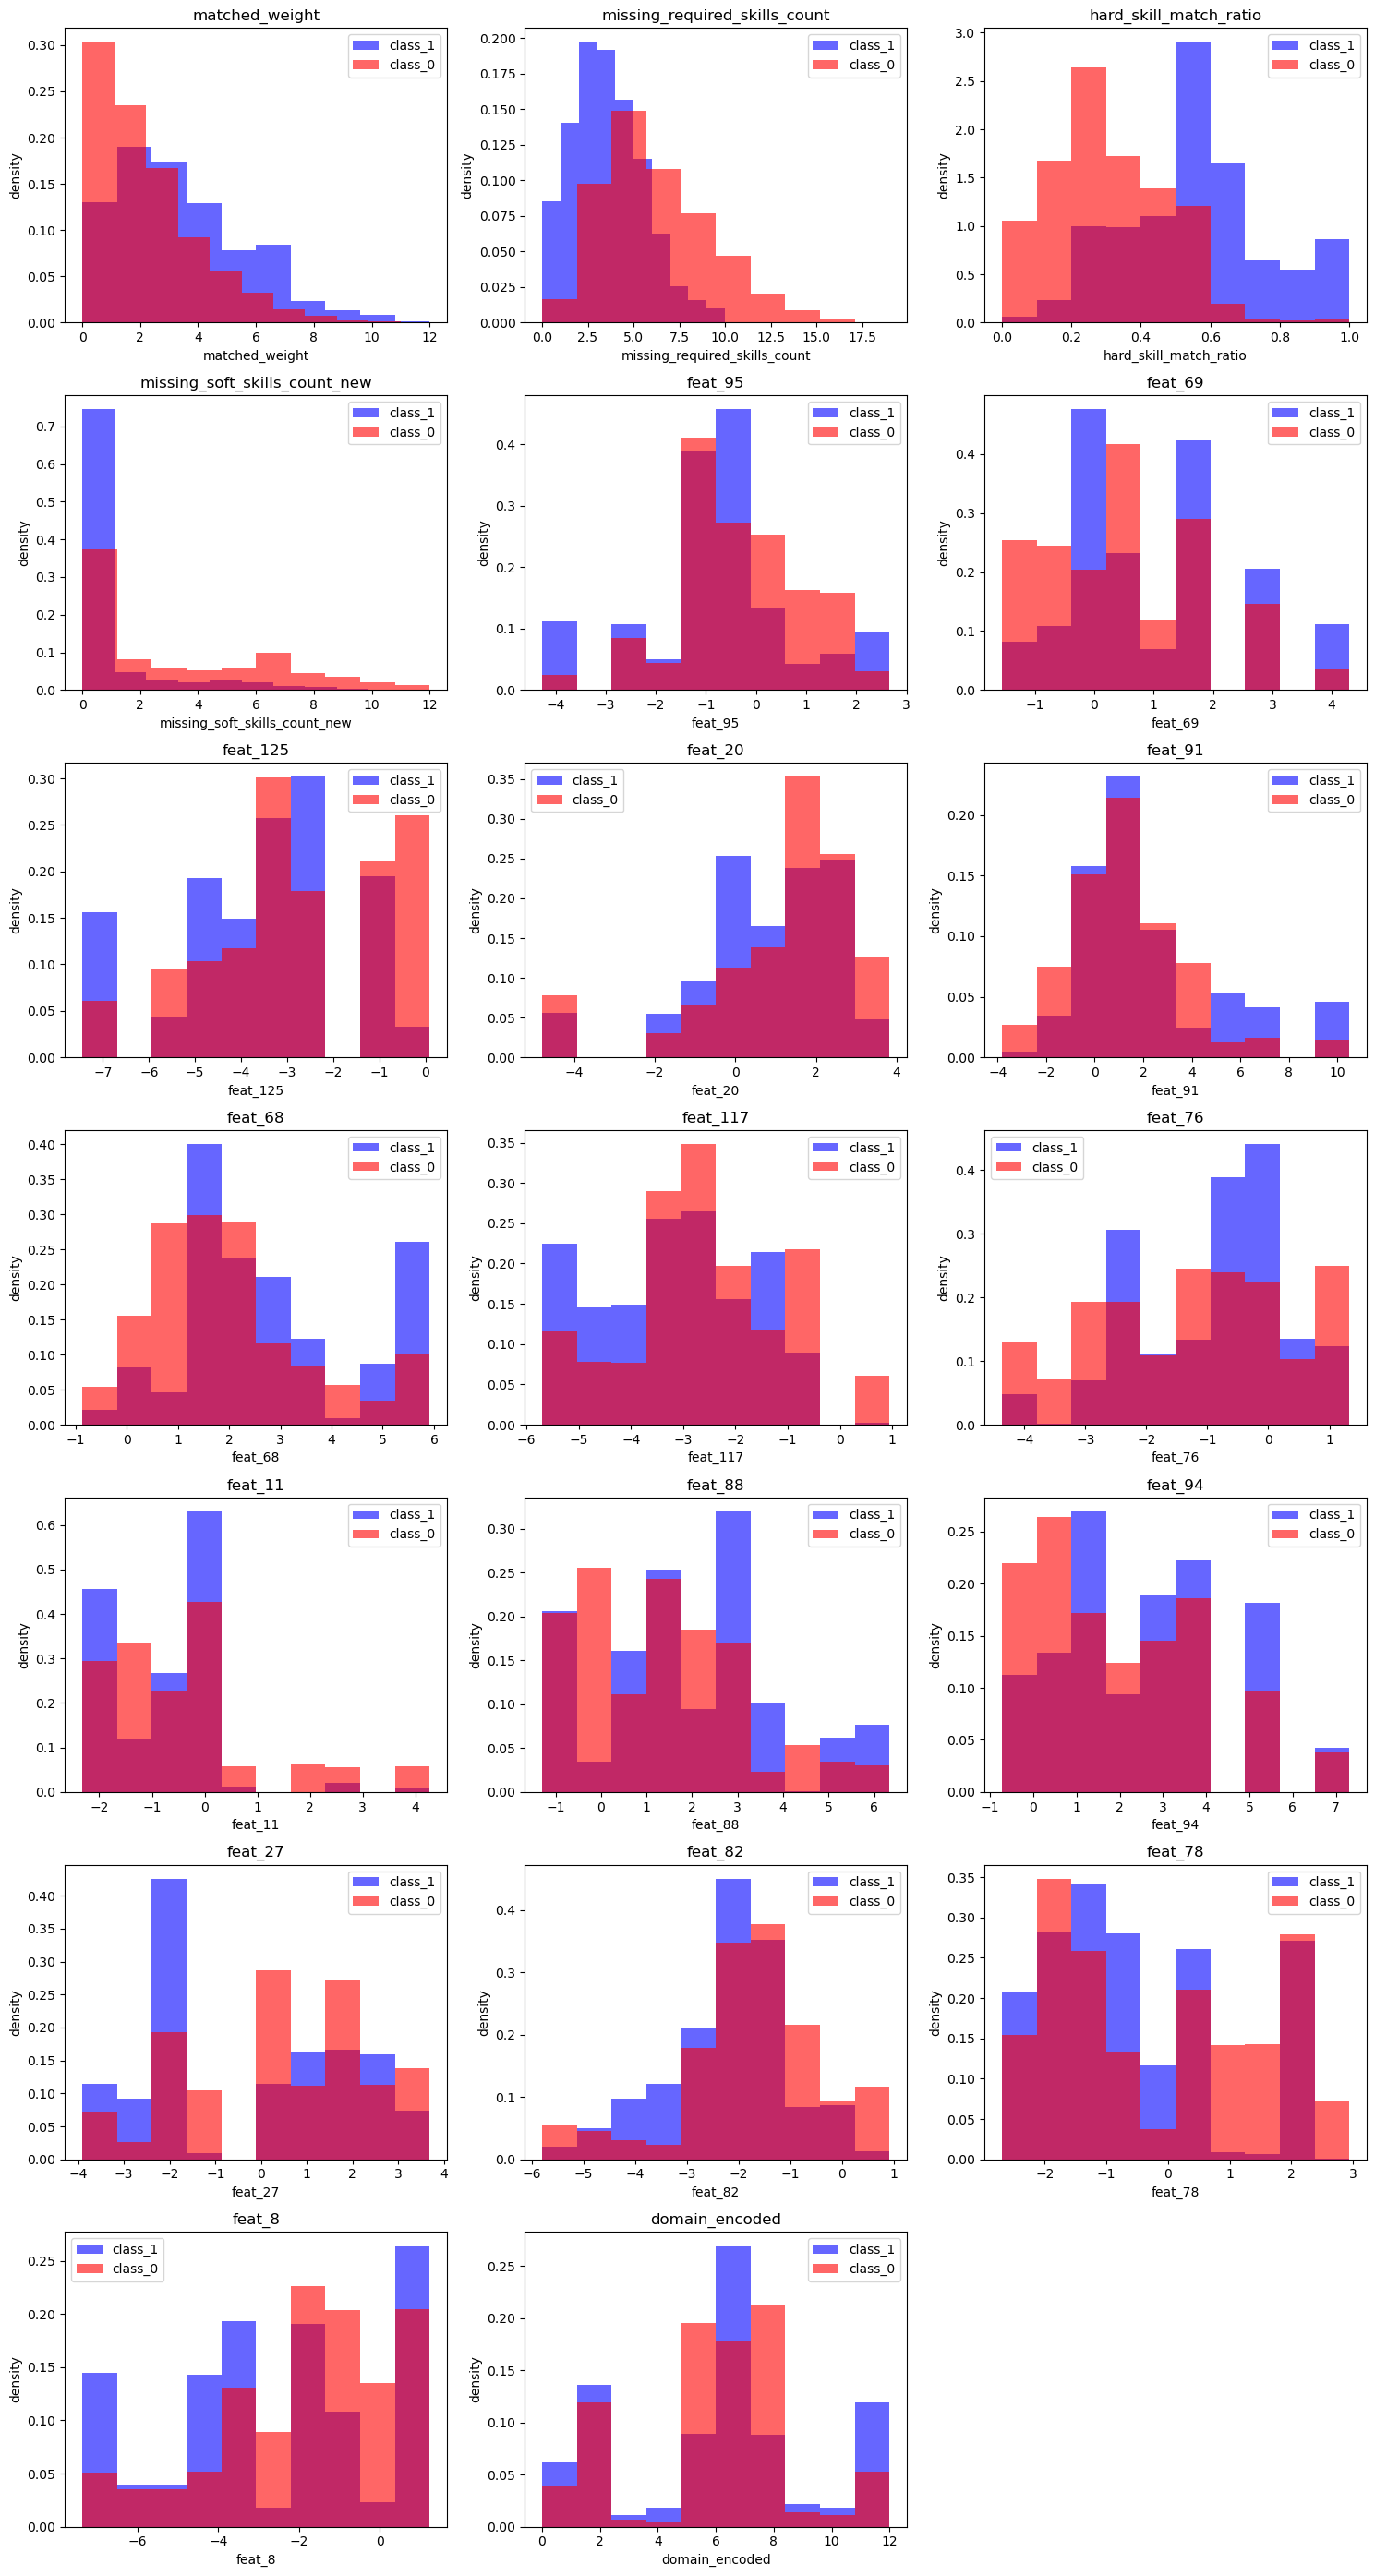

In [ ]:
import math

cols = df_model_encoded.columns.drop('target')
n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(cols):
    axes[i].hist(
        df_model_encoded[df_model_encoded['target'] == 1][feature],
        color='blue',
        alpha=0.6,
        density=True,
        label='class_1'
    )
    axes[i].hist(
        df_model_encoded[df_model_encoded['target'] == 0][feature],
        color='red',
        alpha=0.6,
        density=True,
        label='class_0'
    )

    axes[i].set_title(feature)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('density')
    axes[i].legend()


for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()
plt.show()

 validation 
--- Final Model Metrics ---
Accuracy Score: 0.8524
F1 Score: 0.7408

Classification Report:
Train
--- Final Model Metrics ---
Accuracy Score: 0.8493
F1 Score: 0.7370

Classification Report:


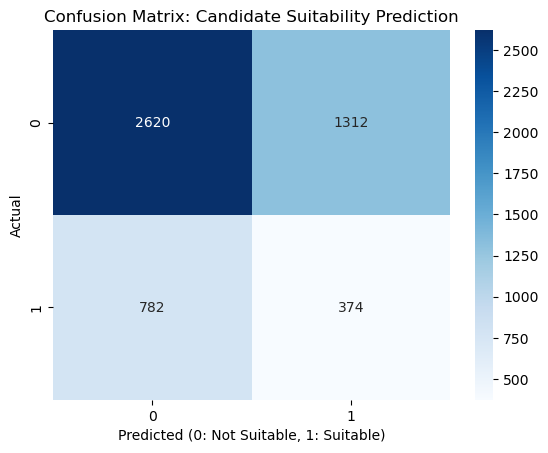

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt



X_train, X_, y_train, y_ = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X, y, test_size=0.5, random_state=42)


model = LogisticRegression(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# 3. Evaluation
y_pred_val = model.predict(X_val)
y_pred_train = model.predict(X_train)

print(" validation ")
print("--- Final Model Metrics ---")
print(f"Accuracy Score: {accuracy_score(y_val, y_pred_val):.4f}")
print(f"F1 Score: {f1_score(y_val, y_pred_val):.4f}")
print("\nClassification Report:")

print("Train")
print("--- Final Model Metrics ---")
print(f"Accuracy Score: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"F1 Score: {f1_score(y_train, y_pred_train):.4f}")
print("\nClassification Report:")


sns.heatmap(confusion_matrix(y_test, y_pred_val), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: Candidate Suitability Prediction")
plt.xlabel("Predicted (0: Not Suitable, 1: Suitable)")
plt.ylabel("Actual")
plt.show()

In [ ]:
model = LogisticRegression(
    C=0.01,
    class_weight='balanced',
    solver='liblinear',
    random_state=42
)
model.fit(X_train,y_train)

y_pred_val = model.predict(X_val)
y_pred_train = model.predict(X_train)


print(" validation ")
print("--- Final Model Metrics ---")
print(f"Accuracy Score: {accuracy_score(y_val, y_pred_val):.4f}")
print(f"F1 Score: {f1_score(y_val, y_pred_val):.4f}")
print("\nClassification Report:")

print("Train")
print("--- Final Model Metrics ---")
print(f"Accuracy Score: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"F1 Score: {f1_score(y_train, y_pred_train):.4f}")
print("\nClassification Report:")


print(f"diff between train and validation f1 score: {f1_score(y_val, y_pred_val) - f1_score(y_train, y_pred_train)}")

 validation 
--- Final Model Metrics ---
Accuracy Score: 0.8406
F1 Score: 0.7248

Classification Report:
Train
--- Final Model Metrics ---
Accuracy Score: 0.8382
F1 Score: 0.7226

Classification Report:
diff between train and validation f1 score: 0.0021771490987989583


In [ ]:
from sklearn.model_selection import GridSearchCV, learning_curve

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid_search = GridSearchCV(
    LogisticRegression(class_weight='balanced', random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}


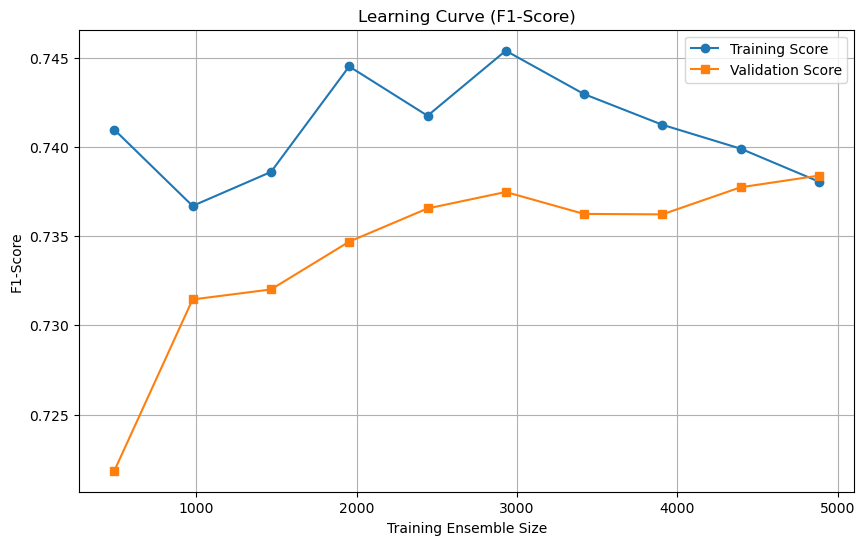

In [ ]:
def plot_learning_curve(estimator, X, y):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=5, scoring='f1',
        train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, label='Training Score', marker='o')
    plt.plot(train_sizes, test_mean, label='Validation Score', marker='s')

    plt.title('Learning Curve (F1-Score)')
    plt.xlabel('Training Ensemble Size')
    plt.ylabel('F1-Score')
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

plot_learning_curve(best_model, X_train, y_train)

In [ ]:
best_model.fit(X_train,y_train)

y_pred_val = best_model.predict(X_val)
y_pred_train = best_model.predict(X_train)
print(" validation ")
print("--- Final Model Metrics ---")
print(f"Accuracy Score: {accuracy_score(y_val, y_pred_val):.4f}")
print(f"F1 Score: {f1_score(y_val, y_pred_val):.4f}")


print("Train")
print("--- Final Model Metrics ---")
print(f"Accuracy Score: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"F1 Score: {f1_score(y_train, y_pred_train):.4f}")

 validation 
--- Final Model Metrics ---
Accuracy Score: 0.8522
F1 Score: 0.7405
Train
--- Final Model Metrics ---
Accuracy Score: 0.8496
F1 Score: 0.7376


In [ ]:
y_test_pred = best_model.predict(X_test)
y_test_scores = best_model.predict_proba(X_test)[:, 1]

print("--- Final Test Results ---")
print(classification_report(y_test, y_test_pred))

--- Final Test Results ---
              precision    recall  f1-score   support

           0       0.95      0.84      0.89      3932
           1       0.62      0.86      0.72      1156

    accuracy                           0.85      5088
   macro avg       0.78      0.85      0.81      5088
weighted avg       0.88      0.85      0.85      5088



In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, classification_report

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train),
    random_state=42
)
'''
scale_pos_weight: Calculates the ratio between negative and positive
classes to penalize the model more for misclassifying
the minority (Suitable) class, effectively handling Class Imbalance without
losing potential candidates.
'''

xgb_model.fit(X_train, y_train)


y_xgb_pred = xgb_model.predict(X_test)
xgb_f1 = f1_score(y_test, y_xgb_pred)

print(f"Logistic Regression F1: 0.7200")
print(f"XGBoost F1-Score: {xgb_f1:.4f}")


if xgb_f1 > 0.72:
    print("\nConclusion: XGBoost performed better, proving the data has Non-Linear patterns.")
else:
    print("\nConclusion: No significant jump, the bottleneck might be in the Features themselves.")

Logistic Regression F1: 0.7200
XGBoost F1-Score: 0.9473

Conclusion: XGBoost performed better, proving the data has Non-Linear patterns.


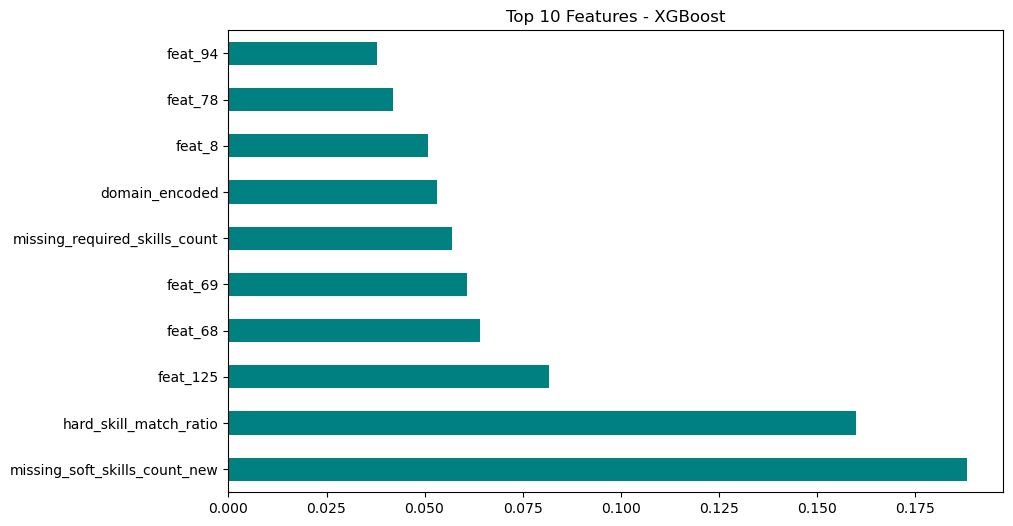

In [ ]:
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 Features - XGBoost')
plt.show()